In [152]:
setwd("/home/mjehangir/telomere-sv-analysis/data/")


In [153]:

library(tidyverse)      # Includes: dplyr, ggplot2, tidyr, readr, stringr, purrr, forcats
library(tibble)
library(scales)         # For axis formatting
library(GenomicRanges)
library(IRanges)
library(lme4)           # Linear mixed-effects models
library(lmerTest)       # P-values for lmer
library(survival)       # Survival analysis
library(survminer)      # Visualization of survival curves
library(gridExtra)      # Side-by-side plots
library(grid)           # Low-level plot adjustments
library(ggforce)        # For geom_sina and advanced shapes
library(ggpubr)         # For stat_compare_means and easy annotations
library(ggsci)          # Nature/Science journal color palettes
library(ComplexHeatmap) # Advanced heatmaps
library(circlize)       # Required for circular layouts/ComplexHeatmap colors
library(forcats)
library(ggforce)
library(dplyr)



In [154]:
ecbed <- read.delim("all_samples_reconstruct.ecDNA.filtered.bed",
#ecbed <- read.delim("all_samples_decoil.ecDNA.filtered.bed",

                    header = TRUE, sep = "\t")
head(ecbed)


,X.chr,start,end,circ_id,fragment_id,strand,coverage,estimated_proportions,X2436A
,<chr>,<chr>,<chr>,<chr>,<chr>,<chr>,<chr>,<chr>,<chr>
1,chr1,196089010,196200712,1,989.993,+,107,108,2436A
2,chr1,196202843,196213045,1,1001,+,109,108,2436A
3,chr14,100384316,100903138,25,12905,+,72,72,2436A
4,chr6,132892661,132908593,18,6365,-,188,58,2436A
5,chr7,145478082,145544265,18,7405.7413.7417,+,229,58,2436A
6,chr7,145467433,145478082,18,7401,-,180,58,2436A


In [155]:
colnames(ecbed)[9] <- "sample"
colnames(ecbed)[1] <- "chr"

head(ecbed)


,chr,start,end,circ_id,fragment_id,strand,coverage,estimated_proportions,sample
,<chr>,<chr>,<chr>,<chr>,<chr>,<chr>,<chr>,<chr>,<chr>
1,chr1,196089010,196200712,1,989.993,+,107,108,2436A
2,chr1,196202843,196213045,1,1001,+,109,108,2436A
3,chr14,100384316,100903138,25,12905,+,72,72,2436A
4,chr6,132892661,132908593,18,6365,-,188,58,2436A
5,chr7,145478082,145544265,18,7405.7413.7417,+,229,58,2436A
6,chr7,145467433,145478082,18,7401,-,180,58,2436A


In [156]:
# Load chr arm lengths
chr_arm_size <- read.csv("chm13_p_q_arm_length.tsv", header = TRUE, sep = "\t")

# RTL matrix (assumes tab-delimited, sample IDs as rownames)
telomeres_MAD <- read.table("telomeres_MAD.txt",
                           sep = "\t",
                           header = TRUE,
                           check.names = FALSE)

In [157]:
ecdna <- read.delim("all_samples_summary.tsv", sep = "\t", header = TRUE)


In [158]:
head(chr_arm_size)
head(telomeres_MAD)
head(ecbed)

,Chromosome,Start,End,Length,Arm
,<chr>,<int>,<int>,<int>,<chr>
1,chr1,0,124048267,124048267,p
2,chr1,124048267,248387328,124339061,q
3,chr10,0,40649191,40649191,p
4,chr10,40649191,134758134,94108943,q
5,chr11,0,52743313,52743313,p
6,chr11,52743313,135127769,82384456,q


,Sample_prefix,chr,final_average_TL_p75,chr_order,arm,final_average_TL_p75_kb,direction.x,chr_arm,median_TL,mad_TL,norm_TL,direction.y,direction
,<chr>,<chr>,<dbl>,<int>,<chr>,<dbl>,<chr>,<chr>,<dbl>,<dbl>,<dbl>,<chr>,<chr>
1,2436A,chr1p,5221.000,1,p,5.221000,Negative,chr1p,5303.000,1180.083,-0.06948662,Negative,Neutral
2,2436A,chr1q,5051.167,1,q,5.051167,Negative,chr1q,5303.000,1180.083,-0.21340301,Negative,Negative
3,3188,chr1p,1642.500,1,p,1.642500,Negative,chr1p,2824.125,399.500,-2.95775970,Negative,Neutral
4,3188,chr1q,3086.500,1,q,3.086500,Negative,chr1q,2824.125,399.500,0.65675845,Negative,Negative
5,3988,chr1p,2347.500,1,p,2.347500,Negative,chr1p,5689.500,1319.250,-2.53325753,Negative,Neutral
6,3988,chr1q,5083.000,1,q,5.083000,Negative,chr1q,5689.500,1319.250,-0.45973091,Negative,Negative


,chr,start,end,circ_id,fragment_id,strand,coverage,estimated_proportions,sample
,<chr>,<chr>,<chr>,<chr>,<chr>,<chr>,<chr>,<chr>,<chr>
1,chr1,196089010,196200712,1,989.993,+,107,108,2436A
2,chr1,196202843,196213045,1,1001,+,109,108,2436A
3,chr14,100384316,100903138,25,12905,+,72,72,2436A
4,chr6,132892661,132908593,18,6365,-,188,58,2436A
5,chr7,145478082,145544265,18,7405.7413.7417,+,229,58,2436A
6,chr7,145467433,145478082,18,7401,-,180,58,2436A


In [159]:
nrow(ecbed)
nrow(ecdna)


[1] 118

[1] 290

In [160]:
head(ecdna)


,sample,circ_id,chr_origin,size.MB.,label,topology_idx,topology_name,estimated_proportions
,<chr>,<int>,<chr>,<dbl>,<chr>,<int>,<chr>,<int>
1,2436A,0,chr1,0.015960,,0,simple_circle,95
2,2436A,1,chr1,0.121904,ecDNA,1,simple_sv,108
3,2436A,2,chr2,0.013592,,0,simple_circle,89
4,2436A,3,chr3,0.004469,,0,simple_circle,1678
5,2436A,26,"chr15,chr18",0.004089,,4,multi_region_inter_chr,2627
6,2436A,5,"chr15,chr18",0.006083,,4,multi_region_inter_chr,1425


In [161]:
# Check unique topologies and labels
table(ecdna$topology_name)
table(ecdna$label)


             foldbacks multi_region_inter_chr multi_region_intra_chr 
                     3                     22                     42 
         simple_circle    simple_duplications              simple_sv 
                   208                      1                     14 


      ecDNA 
  245    45 

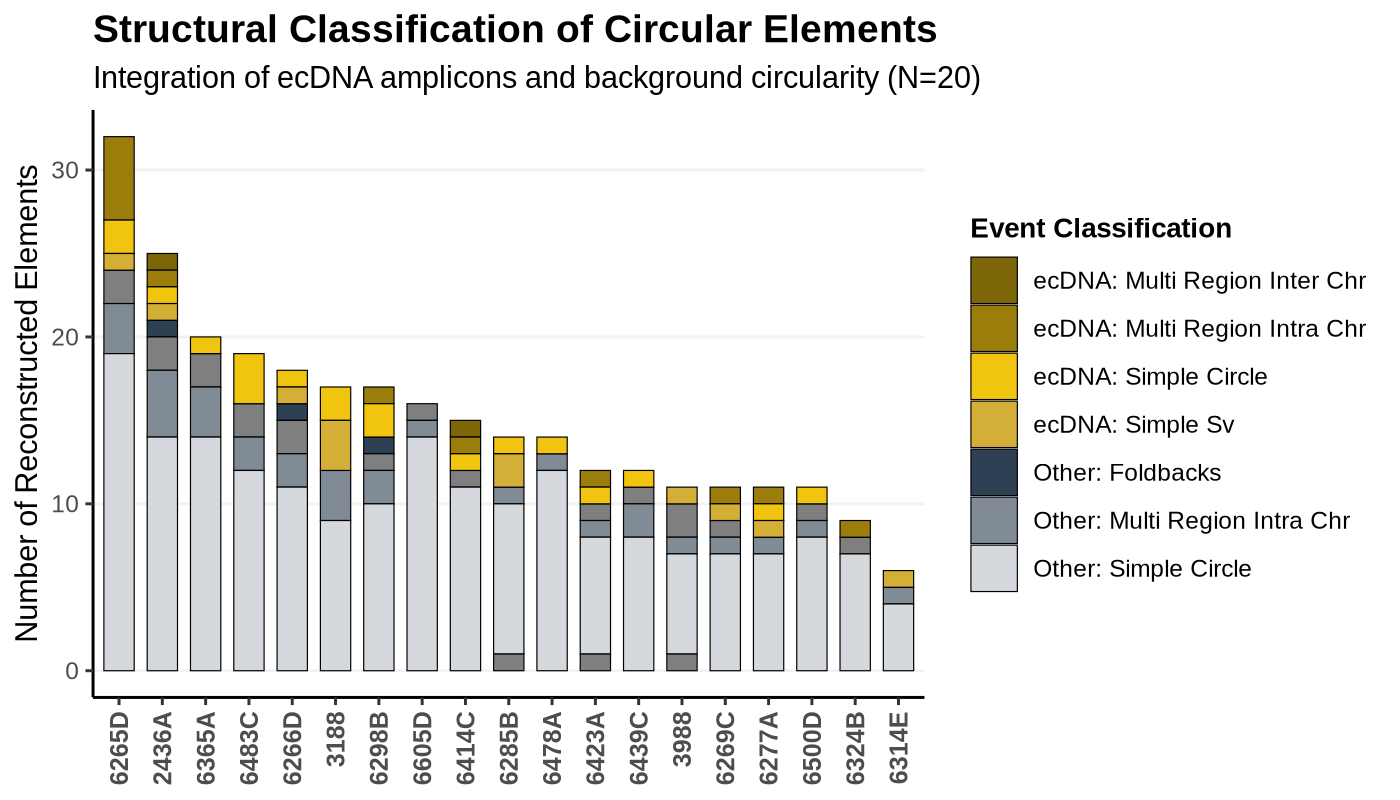

In [162]:


options(repr.plot.width = 7, repr.plot.height = 4, repr.plot.res = 200)

# --- 1. Refine Event Types for Biological Clarity ---
ecdna_plot_df <- ecdna %>%
  mutate(
    # Clean up names for a cleaner legend
    clean_topology = gsub("_", " ", topology_name) %>% tools::toTitleCase(),
    # Create a descriptive category
    plot_type = ifelse(label == "ecDNA", 
                       paste("ecDNA:", clean_topology), 
                       paste("Other:", clean_topology))
  ) %>%
  group_by(sample, plot_type) %>%
  summarise(count = n(), .groups = "drop")

# --- 2. Create the Publication-Quality Plot ---
# We sort the x-axis by the total count of events per sample
ggplot(ecdna_plot_df, aes(x = reorder(sample, -count, sum), y = count, fill = plot_type)) +
  geom_bar(stat = "identity", position = "stack", color = "black", size = 0.2, width = 0.7) +
  # Custom Golden-to-Earth palette for publication contrast
  scale_fill_manual(values = c(
    "ecDNA: Simple Circle"         = "#F1C40F", # Bright Gold
    "ecDNA: Simple Sv"             = "#D4AF37", # Metallic Gold
    "ecDNA: Multi Region Intra Chr"= "#9A7D0A", # Bronze
    "ecDNA: Multi Region Inter Chr"= "#7D6608", # Dark Olive/Gold
    "Other: Simple Circle"         = "#D5D8DC", # Light Grey
    "Other: Multi Region Intra Chr"= "#808B96", # Slate Grey
    "Other: Foldbacks"             = "#2E4053"  # Deep Charcoal
  )) +
  theme_classic() +
  labs(
    title = "Structural Classification of Circular Elements",
    subtitle = "Integration of ecDNA amplicons and background circularity (N=20)",
    x = NULL,
    y = "Number of Reconstructed Elements",
    fill = "Event Classification"
  ) +
  theme(
    axis.text.x = element_text(angle = 90, vjust = 0.5, hjust = 1, face = "bold", size = 9),
    legend.position = "right",
    legend.title = element_text(face = "bold", size = 10),
    plot.title = element_text(face = "bold", size = 14),
    panel.grid.major.y = element_line(color = "grey95")
  )

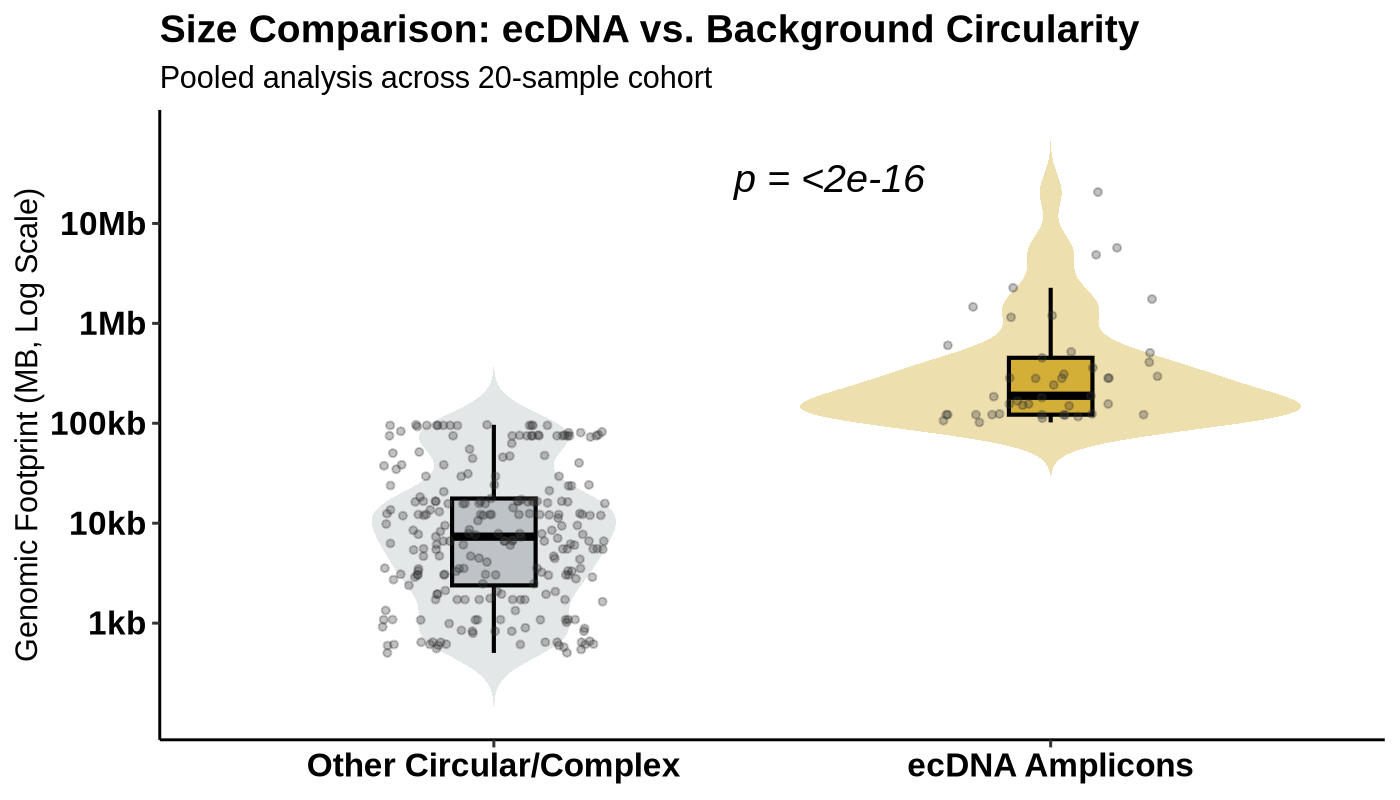

In [163]:

# --- 1. Prepare Plotting Data ---
df_size_comp <- ecdna %>%
  mutate(Category = ifelse(label == "ecDNA", "ecDNA Amplicons", "Other Circular/Complex"),
         Category = factor(Category, levels = c("Other Circular/Complex", "ecDNA Amplicons")))

# --- 2. Generate the Publication-Ready Comparison ---
ggplot(df_size_comp, aes(x = Category, y = size.MB., fill = Category)) +
  # Use a Violin plot to show distribution density
  geom_violin(trim = FALSE, alpha = 0.4, color = NA) +
  # Overlay a Boxplot for quartiles
  geom_boxplot(width = 0.15, color = "black", outlier.shape = NA, size = 0.7) +
  # Add jittered points for the actual data
  geom_jitter(width = 0.2, alpha = 0.3, size = 1, color = "grey20") +
  
  # Log scale is critical because sizes vary by orders of magnitude
  scale_y_log10(breaks = c(0.001, 0.01, 0.1, 1, 10),
                labels = c("1kb", "10kb", "100kb", "1Mb", "10Mb")) +
  
  # Golden Theme
  scale_fill_manual(values = c("Other Circular/Complex" = "#BDC3C7", "ecDNA Amplicons" = "#D4AF37")) +
  
  # Statistical Comparison (Wilcoxon rank-sum test)
  stat_compare_means(method = "wilcox.test", label = "p.format", 
                     label.x = 1.5, size = 5, fontface = "italic") +
  
  theme_classic() +
  labs(
    title = "Size Comparison: ecDNA vs. Background Circularity",
    subtitle = "Pooled analysis across 20-sample cohort",
    x = NULL,
    y = "Genomic Footprint (MB, Log Scale)"
  ) +
  theme(
    legend.position = "none",
    axis.text = element_text(size = 12, color = "black", face = "bold"),
    plot.title = element_text(face = "bold", size = 14)
  )

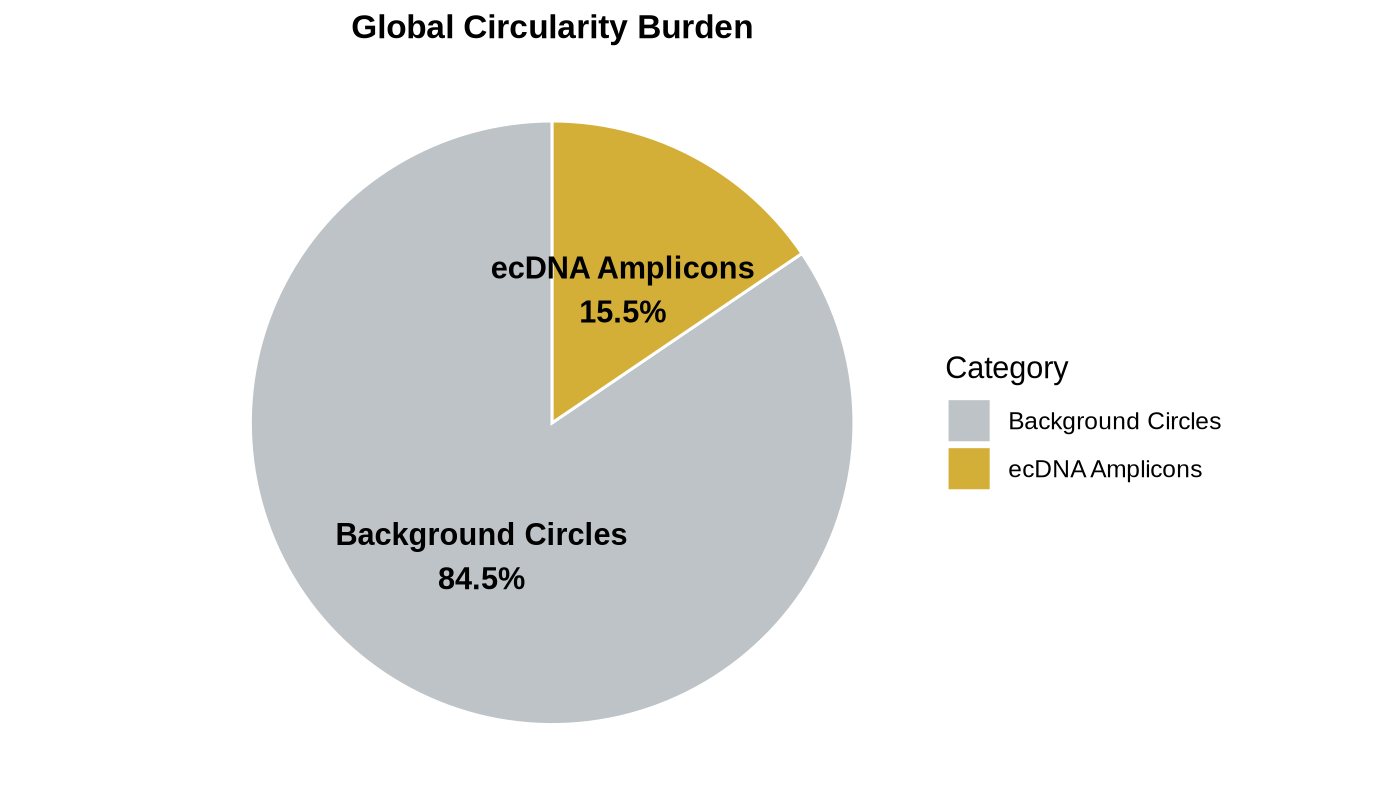

In [164]:
# --- 2. Global Pie Chart (All circular elements) ---
# Separates ecDNA amplicons from the background pool
pie_df <- ecdna %>%
  mutate(Category = ifelse(label == "ecDNA", "ecDNA Amplicons", "Background Circles")) %>%
  group_by(Category) %>%
  summarise(count = n()) %>%
  mutate(perc = count / sum(count) * 100,
         label = paste0(Category, "\n", round(perc, 1), "%"))

p1 <- ggplot(pie_df, aes(x = "", y = count, fill = Category)) +
  geom_bar(stat = "identity", width = 1, color = "white") +
  coord_polar("y", start = 0) +
  scale_fill_manual(values = c("ecDNA Amplicons" = "#D4AF37", "Background Circles" = "#BDC3C7")) +
  theme_void() +
  labs(title = "Global Circularity Burden") +
  geom_text(aes(label = label), position = position_stack(vjust = 0.5), fontface = "bold") +
  theme(plot.title = element_text(hjust = 0.5, face = "bold", size = 12))
p1

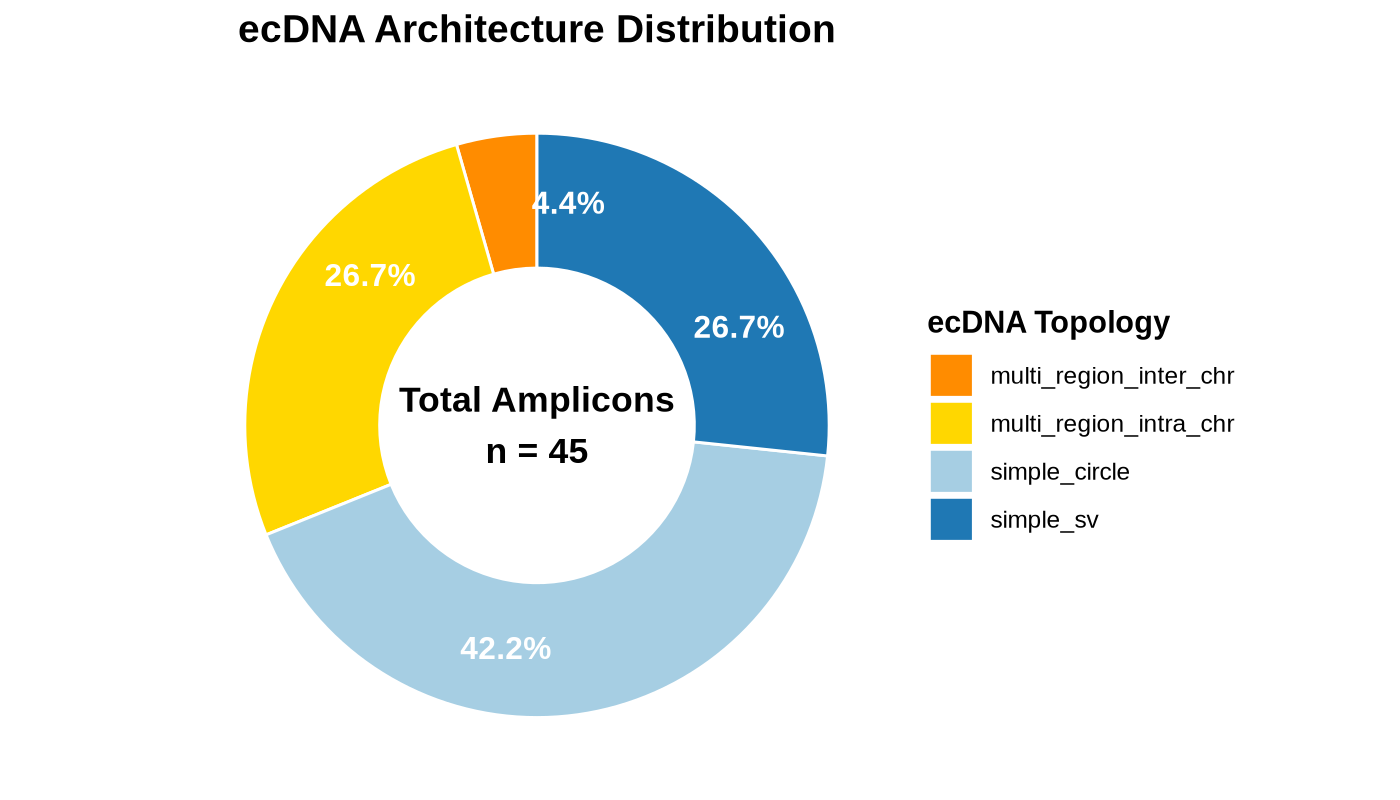

In [165]:

# 1. Define your specific Palette (Matched exactly to table names)
topo_colors <- c(
  "simple_circle"          = "#A6CEE3",
  "simple_sv"              = "#1F78B4",
  "simple_duplications"    = "#B2DF8A",
  "foldbacks"              = "#E31A1C",
  "multi_region_inter_chr" = "#FF8C00", 
  "multi_region_intra_chr" = "#FFD700"  
)

# 2. Data Prep: Calculate percentages and label positions
donut_df <- ecdna %>%
  filter(label == "ecDNA") %>%
  mutate(topology_name = tolower(gsub(" ", "_", topology_name))) %>%
  group_by(topology_name) %>%
  summarise(count = n(), .groups = "drop") %>%
  mutate(
    percentage = count / sum(count) * 100,
    # Create the label string
    label_text = paste0(round(percentage, 1), "%"),
    # Calculate position for labels (midpoint of each segment)
    ymax = cumsum(count),
    ymin = c(0, head(ymax, n = -1)),
    label_pos = (ymax + ymin) / 2
  )

# 3. Plotting the Donut with Labels
p_donut_pct <- ggplot(donut_df, aes(x = 2, y = count, fill = topology_name)) +
  geom_bar(stat = "identity", color = "white", size = 0.5) +
  coord_polar("y", start = 0) +
  xlim(0.5, 2.5) + # Creates the donut hole
  scale_fill_manual(values = topo_colors, name = "ecDNA Topology") +
  # Add the percentage labels
  geom_text(aes(y = label_pos, label = label_text), 
            color = "white", fontface = "bold", size = 4) +
  theme_void() +
  labs(title = "ecDNA Architecture Distribution") +
  # Central "Total" count
  annotate("text", x = 0.5, y = 0, 
           label = paste0("Total Amplicons\nn = ", sum(donut_df$count)), 
           fontface = "bold", size = 4.5, color = "black") +
  theme(
    plot.title = element_text(hjust = 0.5, face = "bold", size = 14),
    legend.position = "right",
    legend.title = element_text(face = "bold")
  )

p_donut_pct

In [166]:

# We use 'matches' to find the chromosome column regardless of 'origin' vs 'origins'
ecdna_key <- ecdna %>%
  select(sample, circ_id, 
         Chromosome = matches("chr_origin"), 
         topology_name, label) %>%
  # Handle cases like "chr15,chr18" by splitting into two rows
  separate_rows(Chromosome, sep = ",") %>%
  # Ensure 'Chromosome' matches the format in ecDNA_tel (e.g., "chr1")
  mutate(Chromosome = trimws(as.character(Chromosome)))

# --- 2. Clean the Telomere Data ---
# We ensure the join keys are exactly the same type (character/integer)
tel_data <- ecDNA_tel %>%
  mutate(
    sample = as.character(sample),
    circ_id = as.integer(circ_id),
    Chromosome = as.character(Chromosome)
  )

# --- 3. The Final Join ---
# We join on the three pillars: Sample, Circle ID, and Chromosome
merged_arms <- tel_data %>%
  left_join(ecdna_key, by = c("sample", "circ_id", "Chromosome")) %>%
  # Fill in the "Linear" gaps for arms without ecDNA
  mutate(
    topology_name = ifelse(is.na(topology_name), "linear", topology_name),
    label = ifelse(is.na(label), "0", label)
  )

# --- 4. Validation Check ---
print("Merge Summary (Topology Counts per Arm):")
table(merged_arms$topology_name)

head(merged_arms)

[1] "Merge Summary (Topology Counts per Arm):"



multi_region_inter_chr multi_region_intra_chr          simple_circle 
                    17                     38                     19 
             simple_sv 
                    26 

,sample,Chromosome,Arm,chr_arm,start,end,TL_kb,norm_TL,ArmLen,estimated_proportions,fragment_id,circ_id,topology_name,label
,<chr>,<chr>,<chr>,<chr>,<int>,<int>,<chr>,<chr>,<int>,<int>,<chr>,<int>,<chr>,<chr>
1,2436A,chr1,q,chr1q,196089010,196200712,5.05116666666667,-0.213403008262126,124339061,108,989.993,1,simple_sv,ecDNA
2,2436A,chr1,q,chr1q,196202843,196213045,5.05116666666667,-0.213403008262126,124339061,108,1001,1,simple_sv,ecDNA
3,2436A,chr14,q,chr14q,100384316,100903138,3.4906,-1.53582374126121,89761231,72,12905,25,simple_circle,ecDNA
4,2436A,chr6,q,chr6q,132892661,132908593,5.89692857142857,0.50329375447658,112454080,58,6365,18,multi_region_inter_chr,ecDNA
5,2436A,chr7,q,chr7q,145478082,145544265,6.48308333333333,1,98502993,58,7405.7413.7417,18,multi_region_inter_chr,ecDNA
6,2436A,chr7,q,chr7q,145467433,145478082,6.48308333333333,1,98502993,58,7401,18,multi_region_inter_chr,ecDNA


In [167]:
nrow(merged_arms)

[1] 100

In [168]:
# Consolidate fragments so each ecDNA event counts once per arm
merged_arms_final <- merged_arms %>%
  group_by(sample, circ_id, chr_arm, topology_name, label) %>%
  summarise(
    # Take the average telomere length for that arm
    TL_kb = mean(as.numeric(TL_kb), na.rm = TRUE),
    norm_TL = mean(as.numeric(norm_TL), na.rm = TRUE),
    # Take the single estimated proportion for that circle
    estimated_proportions = max(as.numeric(estimated_proportions)),
    # Calculate the total physical size of all fragments on this arm
    #total_arm_contribution_kb = sum(as.numeric(end) - as.numeric(start)) / 1000,
    #.groups = "drop"
  )

# Check the new count
nrow(merged_arms_final)

`summarise()` has grouped output by 'sample', 'circ_id', 'chr_arm',
'topology_name'. You can override using the `.groups` argument.


[1] 47

In [169]:
write.csv(merged_arms, "/home/mjehangir/telomere-sv-analysis/data/ecDNA_subtypes_tel.csv", row.names = FALSE)

In [135]:
colnames(ecdna)

[1] "sample"                "circ_id"               "chr_origin"           
[4] "size.MB."              "label"                 "topology_idx"         
[7] "topology_name"         "estimated_proportions" "event_type"

In [119]:
ecdna_counts <- ecdna %>%
  filter(label == "ecDNA") %>%
  group_by(sample) %>%
  summarise(ecDNA_count = n(), .groups="drop")

print("Number of ecDNA reconstructions per sample:")
print(ecdna_counts)

[1] "Number of ecDNA reconstructions per sample:"
# A tibble: 18 × 2
   sample ecDNA_count
   <chr>        <int>
 1 2436A            4
 2 3188             5
 3 3988             1
 4 6265D            8
 5 6266D            2
 6 6269C            2
 7 6277A            3
 8 6285B            3
 9 6298B            3
10 6314E            1
11 6324B            1
12 6365A            1
13 6414C            3
14 6423A            2
15 6439C            1
16 6478A            1
17 6483C            3
18 6500D            1


In [19]:
# Ensure last column is sample
#colnames(ecbed)[ncol(ecbed)] <- "sample"

ecbed_counts <- ecbed %>%
  group_by(sample) %>%
  summarise(fragments_count = n(), .groups="drop")

print("Number of ecDNA fragments per sample:")
print(ecbed_counts)

[1] "Number of ecDNA fragments per sample:"
# A tibble: 19 × 2
   sample fragments_count
   <chr>            <int>
 1 2436A               12
 2 3188                 9
 3 3988                 4
 4 6265D               19
 5 6266D                4
 6 6269C                6
 7 6277A                8
 8 6285B                6
 9 6298B                7
10 6314E                3
11 6324B                4
12 6365A                2
13 6414C               17
14 6423A                6
15 6439C                2
16 6478A                2
17 6483C                4
18 6500D                2
19 6605D                1


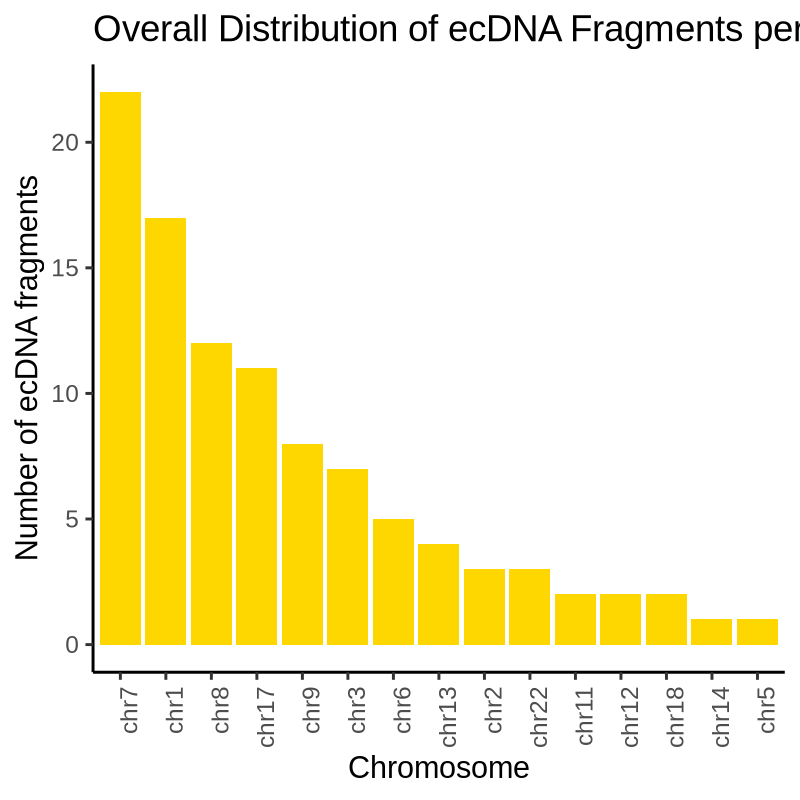

In [20]:
# Remove rows where chr column starts with '#'
ecbed <- ecbed[!grepl("^#", ecbed$chr), ]
# Count fragments per chromosome (overall)
chrom_counts <- ecbed %>%
  group_by(chr) %>%
  summarise(fragment_count = n(), .groups="drop") %>%
  arrange(desc(fragment_count))  # optional: sort by count

# Convert chr to factor with levels in descending order
chrom_counts$chr <- factor(chrom_counts$chr, levels = chrom_counts$chr)
options(repr.plot.width = 4, repr.plot.height = 4, repr.plot.res = 200)

# Plot
p<- ggplot(chrom_counts, aes(x = chr, y = fragment_count)) +
  geom_bar(stat="identity", fill="gold") +
  theme_classic() +
  xlab("Chromosome") +
  ylab("Number of ecDNA fragments") +
  ggtitle("Overall Distribution of ecDNA Fragments per Chromosome") +
  theme(axis.text.x = element_text(angle=90, hjust=1))



p


In [21]:
ggsave(
  #filename = "/home/mjehangir/telomere-sv-analysis/plots/fig6/No_ecDNA_Fragments_chr.pdf",
  plot = p,
  width = 5, height = 5, units = "in",
  dpi = 300
)

ERROR: Error in ggsave(plot = p, width = 5, height = 5, units = "in", dpi = 300): argument "filename" is missing, with no default


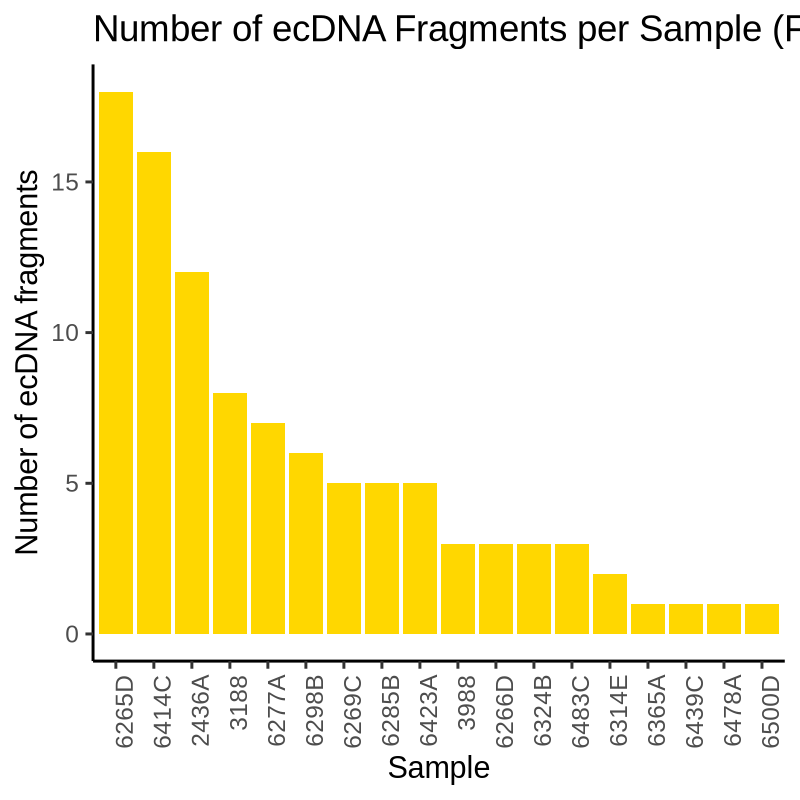

In [22]:
# Count number of ecDNA fragments per sample
fragment_counts <- ecbed %>%
  group_by(sample) %>%
  summarise(fragments_count = n(), .groups="drop") %>%
  arrange(desc(fragments_count))

# Convert sample to factor to preserve descending order
fragment_counts$sample <- factor(fragment_counts$sample, levels = fragment_counts$sample)

# Plot
p <- ggplot(fragment_counts, aes(x = sample, y = fragments_count)) +
  geom_bar(stat="identity", fill="gold") +
  theme_classic() +
  xlab("Sample") +
  ylab("Number of ecDNA fragments") +
  ggtitle("Number of ecDNA Fragments per Sample (Filtered Data)") +
  theme(axis.text.x = element_text(angle=90, hjust=1))


p
ggsave(
  filename = "/home/mjehangir/telomere-sv-analysis/plots/fig6/No_ecDNA_Fragments_Sample.pdf",
  plot = p,
  width = 5, height = 5, units = "in",
  dpi = 300
)




In [66]:
# Find top arms in the newly saved file
ec_with_arm <- read.delim2("/home/mjehangir/telomere-sv-analysis/data/ecDNA_with_tel.bed") 
  head(ecDNA_tel)

,sample,Chromosome,Arm,chr_arm,start,end,TL_kb,norm_TL,ArmLen,estimated_proportions,fragment_id,circ_id
,<chr>,<chr>,<chr>,<chr>,<int>,<int>,<chr>,<chr>,<int>,<int>,<chr>,<int>
1,2436A,chr1,q,chr1q,196089010,196200712,5.05116666666667,-0.213403008262126,124339061,108,989.993,1
2,2436A,chr1,q,chr1q,196202843,196213045,5.05116666666667,-0.213403008262126,124339061,108,1001,1
3,2436A,chr14,q,chr14q,100384316,100903138,3.4906,-1.53582374126121,89761231,72,12905,25
4,2436A,chr6,q,chr6q,132892661,132908593,5.89692857142857,0.50329375447658,112454080,58,6365,18
5,2436A,chr7,q,chr7q,145478082,145544265,6.48308333333333,1,98502993,58,7405.7413.7417,18
6,2436A,chr7,q,chr7q,145467433,145478082,6.48308333333333,1,98502993,58,7401,18


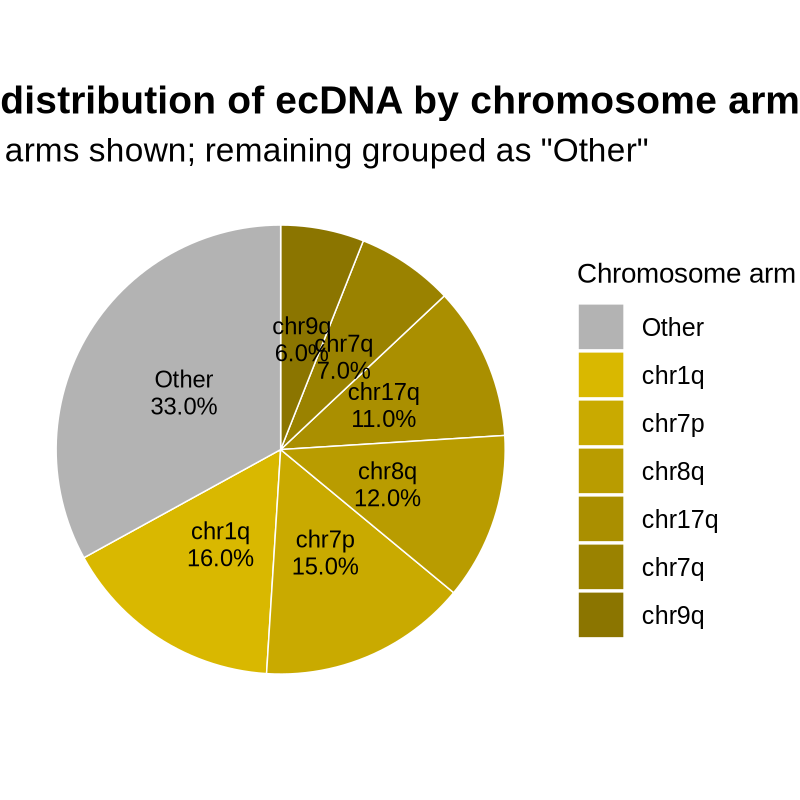

In [67]:

# ───────────────────────────────
# 1) Aggregate ecDNA events across the cohort
# ───────────────────────────────
cohort_counts <- ec_with_arm %>%
  distinct(sample, chr_arm, start, end) %>%  # unique intervals per sample/arm
  count(Arm = chr_arm, name = "events")      # total events per arm across cohort

# ───────────────────────────────
# 2) Keep top-N arms and lump smaller ones to "Other"
# ───────────────────────────────
top_n <- 6
min_frac_label <- 0.03

pie_df <- cohort_counts %>%
  mutate(Arm_lumped = fct_lump_n(Arm, n = top_n, w = events, other_level = "Other")) %>%
  group_by(Arm_lumped) %>%
  summarise(events = sum(events), .groups = "drop") %>%
  mutate(
    frac  = events / sum(events),
    label = if_else(frac >= min_frac_label,
                    paste0(as.character(Arm_lumped), "\n", percent(frac, accuracy = 0.1)),
                    "")
  ) %>%
  mutate(Arm_lumped = fct_reorder(Arm_lumped, events, .desc = TRUE))

# ───────────────────────────────
# 3) Generate colors: gold gradient for top arms, grey for Other
# ───────────────────────────────
arm_levels <- levels(pie_df$Arm_lumped)
top_arms <- arm_levels[arm_levels != "Other"]

# gradient gold for top arms
gold_colors <- scales::seq_gradient_pal("gold2", "gold4", "Lab")(
  seq(0.2, 1, length.out = length(top_arms))
)

# combine with grey for Other
arm_colors <- c(setNames(gold_colors, top_arms),
                Other = "grey70")

# ───────────────────────────────
# 4) Plot publication-quality pie chart
# ───────────────────────────────
options(repr.plot.width = 4, repr.plot.height = 4, repr.plot.res = 200)

p_cohort <- ggplot(pie_df, aes(x = "", y = frac, fill = Arm_lumped)) +
  geom_col(width = 1, color = "white", linewidth = 0.25) +
  coord_polar(theta = "y") +
  geom_text(aes(label = label), position = position_stack(vjust = 0.5),
            size = 3, lineheight = 0.95) +
  scale_fill_manual(values = arm_colors) +
  labs(
    title = "Cohort-wide distribution of ecDNA by chromosome arm",
    subtitle = paste0("Top ", top_n, " arms shown; remaining grouped as \"Other\""),
    fill = "Chromosome arm"
  ) +
  theme_void(base_size = 12) +
  theme(
    legend.title   = element_text(size = 10),
    legend.text    = element_text(size = 9),
    plot.title     = element_text(face = "bold", size = 14, hjust = 0.5),
    plot.subtitle  = element_text(size = 12, hjust = 0.5)
  )

print(p_cohort)

# Save as PDF
ggsave(
  filename = "/home/mjehangir/telomere-sv-analysis/plots/fig6/piechart_ecDNA_prop_per_arm.pdf",
  plot = p_cohort,
  width = 5,
  height = 5,
  units = "in",
  dpi = 300
)
# Optional: save figure
# ggsave("Cohort_ecDNA_by_arm_pie_goldGrey.pdf", p_cohort, width = 8, height = 6, useDingbats = FALSE)


In [69]:

clinical_data <- read_tsv("clinical_data_merged.txt", 
                          na = c("NA", "not available", ""))

head(clinical_data)

Rows: 20 Columns: 11
── Column specification ────────────────────────────────────────────────────────
Delimiter: "\t"
chr (2): ID, surgical
dbl (9): Age, Grade, CDKN2A/B, TP53, ATRX, onco_Alterations, ONT_Alterations...

ℹ Use `spec()` to retrieve the full column specification for this data.
ℹ Specify the column types or set `show_col_types = FALSE` to quiet this message.


ID,Age,Grade,CDKN2A/B,TP53,ATRX,onco_Alterations,ONT_Alterations,surgical,dead,days
<chr>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<chr>,<dbl>,<dbl>
2436A,NA,3,NA,NA,NA,5,40,NA,1,4629
3188,NA,3,NA,NA,NA,16,107,NA,1,1349
3988,0,2,2,0,0,17,105,NA,1,1536
6265D,33,3,1,0,0,42,87,NA,1,950
6266D,40,2,1,0,0,28,105,NA,1,1195
6269C,23,3,2,0,0,14,214,NA,0,2300


In [44]:
# 1. Data Integration & Grouping
merged_data <- clinical_data %>%
  left_join(ecbed %>% count(sample, name = "ecDNA_count"), by = c("ID" = "sample")) %>%
  mutate(
    ecDNA_count = replace_na(ecDNA_count, 0),
    ecDNA_group = factor(if_else(ecDNA_count > median(ecDNA_count), "High", "Low"), levels = c("Low", "High")),
    surv_obj    = Surv(days, dead)
  )
head(merged_data)

ID,Age,Grade,CDKN2A/B,TP53,ATRX,onco_Alterations,ONT_Alterations,surgical,dead,days,ecDNA_count,ecDNA_group,surv_obj
<chr>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<chr>,<dbl>,<dbl>,<int>,<fct>,<Surv>
2436A,NA,3,NA,NA,NA,5,40,NA,1,4629,12,High,"4629, 1"
3188,NA,3,NA,NA,NA,16,107,NA,1,1349,8,High,"1349, 1"
3988,0,2,2,0,0,17,105,NA,1,1536,3,Low,"1536, 1"
6265D,33,3,1,0,0,42,87,NA,1,950,18,High,"950, 1"
6266D,40,2,1,0,0,28,105,NA,1,1195,3,Low,"1195, 1"
6269C,23,3,2,0,0,14,214,NA,0,2300,5,High,"2300, 0"


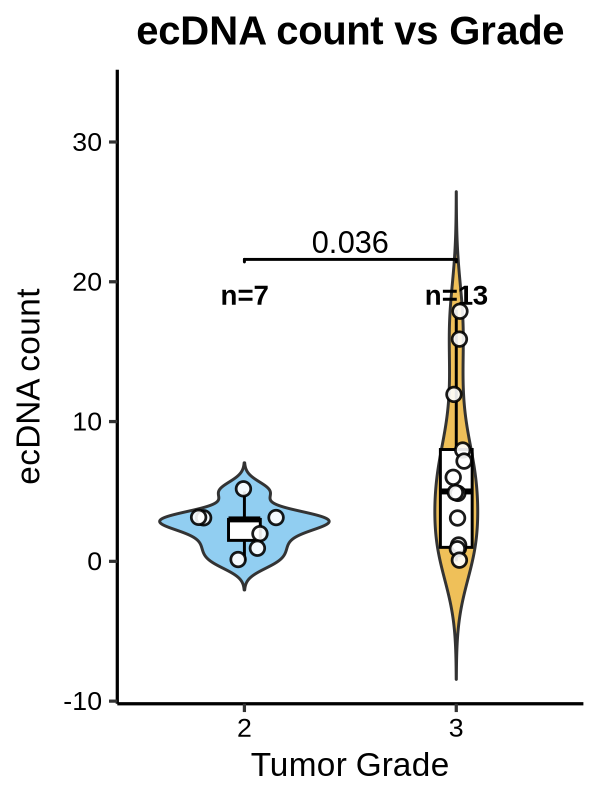

In [171]:

# 1. Prep the data
grade_subset <- merged_data %>%
  filter(Grade %in% c(2, 3)) %>%
  mutate(Grade = factor(Grade)) %>%
  filter(!is.na(ecDNA_count))

# 2. Define colors and dynamic Y limits
grade_cols <- c("2" = "#56B4E9", "3" = "#E69F00") 
y_max <- max(grade_subset$ecDNA_count, na.rm = TRUE)

# 3. Create the Plot
options(repr.plot.width = 3, repr.plot.height = 4, repr.plot.res = 200)

p_violin <- ggplot(grade_subset, aes(x = Grade, y = ecDNA_count, fill = Grade)) +
  # Violin and Boxplot
  geom_violin(trim = FALSE, width = 0.8, alpha = 0.65) +
  geom_boxplot(width = 0.15, outlier.shape = NA, fill = "white", 
               color = "black", linewidth = 0.5) +
  
  # Sina points
  ggforce::geom_sina(shape = 21, size = 2, stroke = 0.7, 
                     fill = "white", alpha = 0.9, maxwidth = 0.5) +
  
  # ADDING 'n' counts at the TOP
  stat_summary(
    fun.data = function(x) data.frame(y = y_max * 1.02, label = paste0("n=", length(x))),
    geom = "text", 
    size = 3.5, 
    fontface = "bold",
    vjust = 0 # Adjusts text to sit above the y coordinate
  ) +
  
  scale_fill_manual(values = grade_cols) +
  
  # Statistical comparison (placed higher than 'n' labels)
  stat_compare_means(
    method = "t.test",
    comparisons = list(c("2", "3")),
    label = "p.format",
    bracket.size = 0.5,
    tip.length = 0.01,
    label.y = y_max * 1.15 # Higher to clear the 'n' labels
  ) +
  
  labs(
    x = "Tumor Grade", 
    y = "ecDNA count",
    title = "ecDNA count vs Grade"
  ) +
  theme_classic(base_size = 12) +
  theme(
    legend.position = "none",
    plot.title = element_text(face = "bold", hjust = 0.5),
    axis.text = element_text(color = "black")
  ) +
  # Expand Y axis upward more to accommodate the stack (data -> n -> p-value)
  scale_y_continuous(expand = expansion(mult = c(0.05, 0.25)))

# Print and Save
print(p_violin)

In [ ]:
ggsave(
  #filename = "/home/mjehangir/telomere-sv-analysis/plots/fig6/viloin_grades.pdf",
  plot = p_violin,
  width = 3,
  height = 4,
  units = "in",
  device = "pdf"
)

In [ ]:
nrow(ecbed)

In [ ]:
options(repr.plot.width = 6, repr.plot.height = 4, repr.plot.res = 200)

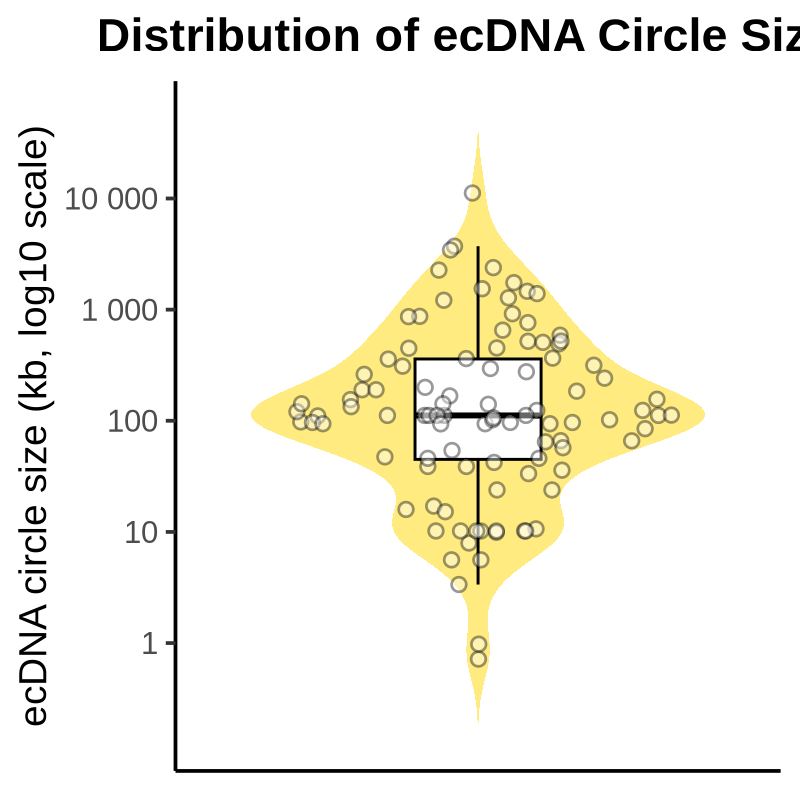

In [46]:

# Compute ecDNA size in kb
ecbed_size <- ecbed %>%
  mutate(
    size_kb = (as.numeric(end) - as.numeric(start)) / 1000
  ) %>%
  filter(!is.na(size_kb), size_kb > 0)

# Plot
p_size_log <- ggplot(ecbed_size, aes(y = size_kb)) +
  geom_violin(aes(x = ""), trim = FALSE, width = 0.9,
              color = NA, alpha = 0.5, fill = "gold") +
  geom_boxplot(aes(x = ""), width = 0.25, outlier.shape = NA,
               fill = "white", color = "black", linewidth = 0.5) +
  ggforce::geom_sina(aes(x = ""), shape = 21, size = 2, stroke = 0.7,
                     fill = "white", alpha = 0.4, maxwidth = 0.8) +
  scale_y_log10(
    labels = scales::label_number(accuracy = 1),   # just numeric labels
    breaks = c(1, 10, 100, 1000, 10000)
  ) +
  labs(
    x = NULL,
    y = "ecDNA circle size (kb, log10 scale)",
    title = "Distribution of ecDNA Circle Sizes"
  ) +
  theme_classic(base_size = 14) +
  theme(
    axis.text.x = element_blank(),
    axis.ticks.x = element_blank(),
    plot.title = element_text(face = "bold", hjust = 0.5)
  )
options(repr.plot.width = 4, repr.plot.height = 4, repr.plot.res = 200)
p_size_log
# Save as PDF
ggsave(
  filename = "/home/mjehangir/telomere-sv-analysis/plots/fig6/size_destributions.pdf",
  plot = p_size_log,
  width = 4,
  height = 4,
  units = "in",
  dpi = 300
)

In [47]:
head(ecdna)

,sample,circ_id,chr_origin,size.MB.,label,topology_idx,topology_name,estimated_proportions,event_type
,<chr>,<int>,<chr>,<dbl>,<chr>,<int>,<chr>,<int>,<chr>
1,2436A,0,chr1,0.015960,,0,simple_circle,95,
2,2436A,1,chr1,0.121904,ecDNA,1,simple_sv,108,ecDNA_simple_sv
3,2436A,2,chr2,0.013592,,0,simple_circle,89,
4,2436A,3,chr3,0.004469,,0,simple_circle,1678,
5,2436A,26,"chr15,chr18",0.004089,,4,multi_region_inter_chr,2627,
6,2436A,5,"chr15,chr18",0.006083,,4,multi_region_inter_chr,1425,


In [48]:
nrow(ecdna)

[1] 290

In [49]:
unique(ecdna$topology_name)

[1] "simple_circle"          "simple_sv"              "multi_region_inter_chr"
[4] "multi_region_intra_chr" "foldbacks"              "simple_duplications"

In [50]:
unique(ecdna$label)

[1] ""      "ecDNA"

In [51]:
unique(ecdna$topology_name)


[1] "simple_circle"          "simple_sv"              "multi_region_inter_chr"
[4] "multi_region_intra_chr" "foldbacks"              "simple_duplications"

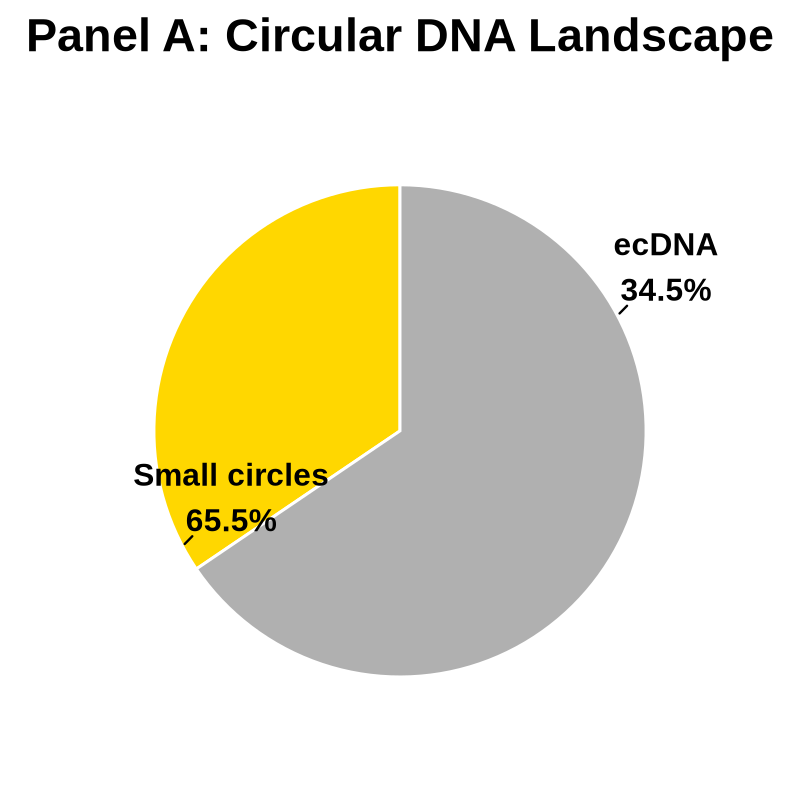

In [72]:

######ecDNA vs Non-ecDNA arms
total_circles <- 290
ecDNA_count   <- 100
small_circles_count <- total_circles - ecDNA_count

# Create dataframe for plotting
pie_df <- data.frame(
  category = c("ecDNA", "Small circles"),
  n = c(ecDNA_count, small_circles_count)
) %>%
  mutate(
    total = sum(n),
    pct   = n / total,
    lbl   = paste0(category, "\n", percent(pct, accuracy=0.1)),
    ypos  = cumsum(n) - n/2
  )

# Colors
fill_map_panelA <- c(
  "ecDNA" = "#FFD700",       # gold
  "Small circles" = "#B0B0B0" # grey
)

# Plot
p_panelA <- ggplot(pie_df, aes(x=1, y=n, fill=category)) +
  geom_col(width=1, color="white") +
  coord_polar(theta="y") +
  geom_text_repel(aes(x=1.5, y=ypos, label=lbl),
                  size=4, fontface="bold", min.segment.length=0,
                  box.padding=0.3, segment.size=0.4) +
  scale_fill_manual(values=fill_map_panelA) +
  xlim(0.5,1.7) +
  theme_void(base_size=14) +
  ggtitle("Panel A: Circular DNA Landscape") +
  theme(
    plot.title = element_text(face="bold", hjust=0.5),
    legend.position="none"
  )
options(repr.plot.width = 4, repr.plot.height = 4, repr.plot.res = 200)

p_panelA
ggsave(
  filename = "/home/mjehangir/telomere-sv-analysis/plots/fig6/decoil_perc_ecdna.pdf",
  plot = p_panelA,
  width = 4,
  height = 4,
  units = "in",
  dpi = 300
)

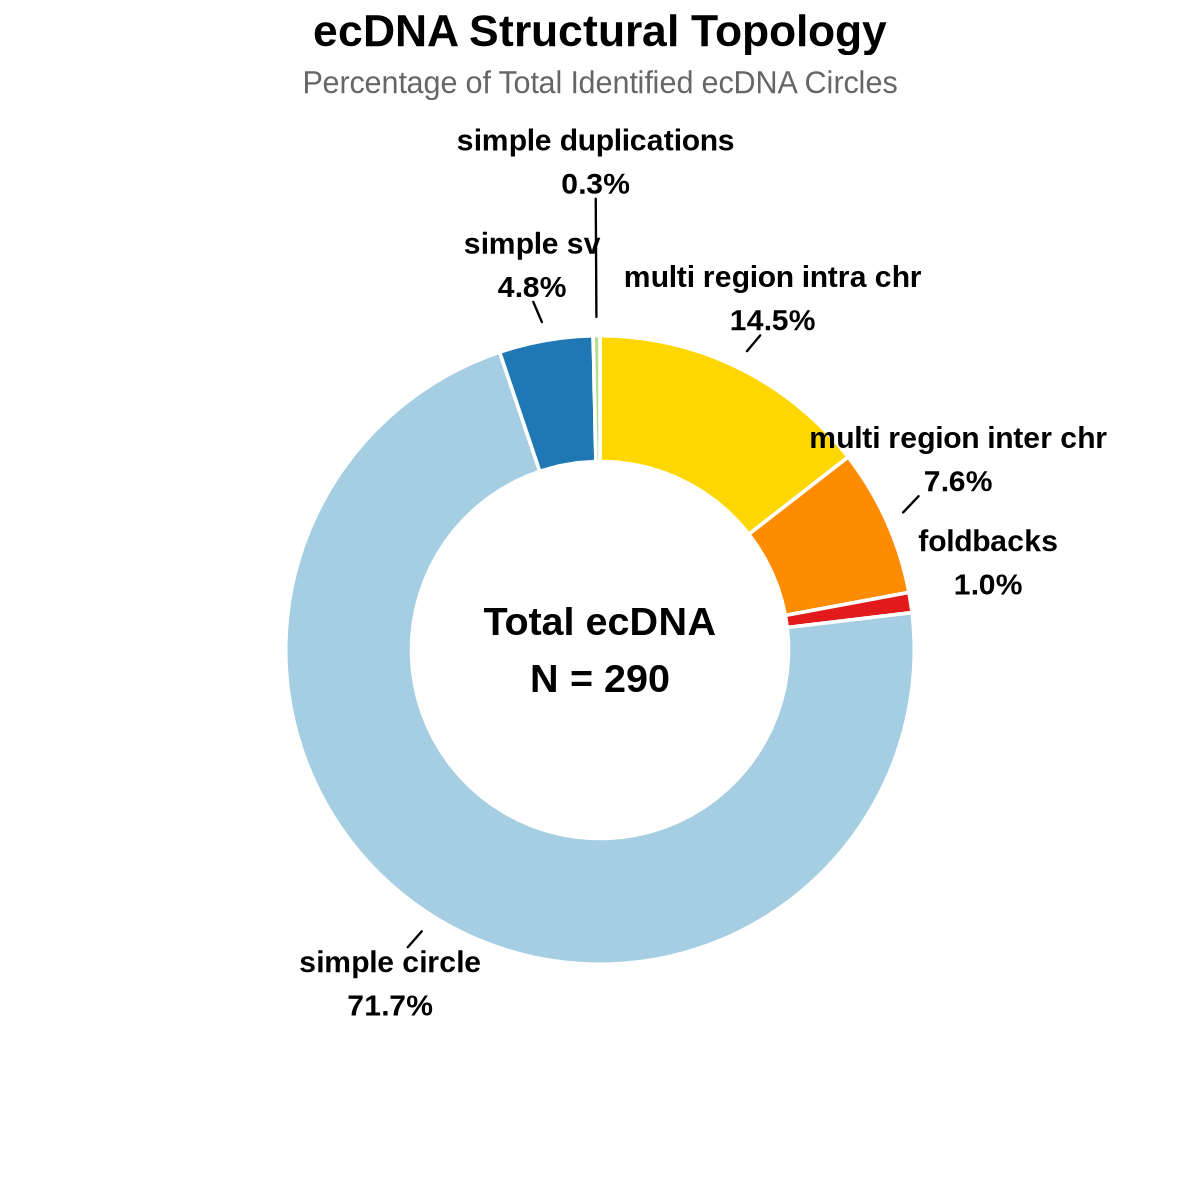

In [71]:

# 1. Classification with exact group logic
donut_df <- ecdna %>%
  mutate(
    topo_clean = trimws(topology_name),
    topo_label = gsub("_", " ", topo_clean),
    group = case_when(
      topo_clean %in% c("simple_circle","simple_sv","simple_duplications") ~ "Simple",
      topo_clean %in% c("foldbacks","multi_region_inter_chr","multi_region_intra_chr") ~ "Complex",
      TRUE ~ "Other"
    )
  ) %>%
  filter(group %in% c("Simple", "Complex")) %>%
  count(group, topo_label) %>%
  arrange(group, desc(n)) %>%
  mutate(
    pct = n / sum(n),
    ymax = cumsum(pct),
    ymin = c(0, head(ymax, n = -1)),
    label_pos = (ymin + ymax) / 2
  )

# 2. Reverting to your specific Color Palette
# Simple (Blues/Greens) vs Complex (Warm/Reds)
topo_colors <- c(
  "simple circle"          = "#A6CEE3",
  "simple sv"              = "#1F78B4",
  "simple duplications"    = "#B2DF8A",
  "foldbacks"              = "#E31A1C",
  "multi region inter chr" = "#FF8C00", # Matches your previous 'ecDNA' orange
  "multi region intra chr" = "#FFD700"  # Matches your previous 'ecDNA' gold
)

# 3. Final Donut Plot
options(repr.plot.width = 6, repr.plot.height = 6, repr.plot.res = 200)

p_donut_clean <- ggplot(donut_df) +
  # The Donut Ring
  geom_rect(aes(ymin = ymin, ymax = ymax, xmin = 1.2, xmax = 2, fill = topo_label), 
            color = "white", linewidth = 0.6) +
  coord_polar(theta = "y") +
  
  # Central N Label
  annotate("text", x = 0, y = 0, 
           label = paste0("Total ecDNA\nN = ", sum(donut_df$n)), 
           size = 5, fontface = "bold") +
  
  # Scientific Labels (Repelled to prevent overlap)
  geom_text_repel(aes(x = 2.1, y = label_pos, 
                      label = paste0(topo_label, "\n", percent(pct, accuracy = 0.1))),
                  size = 3.8, fontface = "bold", segment.size = 0.4,
                  nudge_x = 0.4, direction = "y", box.padding = 0.5) +
  
  scale_fill_manual(values = topo_colors) +
  xlim(0, 2.8) + 
  
  labs(title = "ecDNA Structural Topology",
       subtitle = "Percentage of Total Identified ecDNA Circles") +
  theme_void() +
  theme(
    plot.title = element_text(face = "bold", size = 16, hjust = 0.5),
    plot.subtitle = element_text(size = 11, hjust = 0.5, color = "grey40"),
    legend.position = "none"
  )

print(p_donut_clean)

In [76]:
ggsave(
  filename = "/home/mjehangir/telomere-sv-analysis/plots/fig6/decoil_perc_ecdna_subtypes.pdf",
  plot = p_donut_clean,
  width = 10,
  height = 10,
  units = "in",
  dpi = 300
)